In [1]:
import os
import re
import warnings
from pathlib import Path

import anndata as ad
import gseapy as gp
# import muon as mu
import networkx as nx
import numpy as np
import numpy.testing as npt
import pandas as pd
import scanpy as sc
from scipy.sparse import issparse
import sparse

from joblib import Parallel, delayed
from matplotlib import colors
from matplotlib import pyplot as plt

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

In [2]:
adata = sc.read(Path().home().joinpath("workspace", "easyGSEApy", "tests", "pam_ten_percent_subset.h5ad"))

In [251]:
naive_b.write(Path().home().joinpath("workspace", "easyGSEApy", "tests", "naive_b.h5ad"))

In [3]:
adata.X=adata.layers["counts"]

Just checking the max value to be sure the default is raw counts

In [4]:
def is_integer_array(arr) -> bool:
    """
    Test if an array is really all integers
    """
    if issparse(arr):
        # have to convert to `sparse.COO` here as `scipy.csr_matrix` either no longer or never did support numpy
        # calculations on it
        return not (np.mod(sparse.asCOO(arr), 1) != 0).any()
    else:
        return not (np.mod(arr, 1) != 0).any()

In [5]:
is_integer_array(adata.X)

True

In [6]:
obs_subset: pd.Series | pd.Index | list[str] | None = None
var_subset: pd.Series | pd.Index | list[str] | None = None
groupby: str | None = "disease_class"
referencegroup: str | None = "Neg"
geneset: str | Path | None ="GO_Molecular_Function_2023"
wanted_group: str | None = "SLE"
outdir_path: Path | None = "testing_output"

In [7]:
adata.obs["immune_low_majority"].unique().to_list()

['CD16+ NK cells',
 'Tem/Trm cytotoxic T cells',
 'Non-classical monocytes',
 'Classical monocytes',
 'Tcm/Naive cytotoxic T cells',
 'Tcm/Naive helper T cells',
 'Tem/Temra cytotoxic T cells',
 'Tem/Effector helper T cells',
 'DC2',
 'Naive B cells',
 'MAIT cells',
 'Intermediate macrophages',
 'Memory B cells',
 'pDC',
 'Age-associated B cells',
 'DC1',
 'Regulatory T cells',
 'NK cells',
 'Plasmablasts',
 'Megakaryocytes/platelets',
 'Plasma cells',
 'Megakaryocyte precursor']

In [8]:
adata.obs['type_label']

index
CAAGTTGTCTACCTGC-1_PAM7                                  NKT
GATTCAGCACCCATTC-1_PAM6                              CD56dim
TGCGTGGAGTGGGATC-1_PAM46                          CD8+ CD27+
CCTATTAGTTGCGCAC-1_PAM58    Myeloid derived suppressor cells
AAAGTAGGTCCAACTA-1_PAM54                                 CC2
                                          ...               
CACAGTAAGTTGCAGG-1_PAM34                 CD4+ CD27- effector
AGCCTAAGTGCAACTT-1_PAM61                              Memory
CAGCTAACATGCTAGT-1_PAM53                                 NKT
AGGGAGTTCGGCATCG-1_PAM20                         CD4+ Memory
GCTTGAAAGGAGTTGC-1_PAM46                         CD56+ CD52+
Name: type_label, Length: 58261, dtype: category
Categories (43, object): ['ABCs', 'Activated B Naive', 'CC1', 'CC2', ..., 'Nonclassical monocytes', 'Plasma cells', 'Transitional', 'Undefined']

In [9]:
adata.obs['disease_class'].unique()

['Neg', 'Pos', 'ILE', 'SLE']
Categories (4, object): ['ILE', 'Neg', 'Pos', 'SLE']

In [10]:
naive_b = adata[
    adata.obs[
        (adata.obs["immune_low_majority"] == "Naive B cells") & 
        (adata.obs["disease_class"].isin(("Neg", "SLE")))
    ].index,:].copy()

In [11]:
is_integer_array(naive_b.X)

True

In [12]:
naive_b.layers["counts"] = naive_b.X.copy()

In [13]:
sc.pp.normalize_total(naive_b, target_sum=1e6)
sc.pp.log1p(naive_b)
sc.pp.scale(naive_b)

In [14]:
naive_b.layers["lognorm"] = naive_b.X.copy()

In [15]:
obs_subset = naive_b.obs_names if obs_subset is None else obs_subset
var_subset = naive_b.var_names if var_subset is None else var_subset

In [212]:
gs = gp.GSEA(
    data=pd.DataFrame(
        np.transpose(naive_b.layers["counts"].toarray()), index=var_subset, columns=obs_subset
    ),  # row -> genes, column-> samples
    gene_sets="GO_Biological_Process_2023",
    classes=naive_b.obs["disease_class"],
    permutation_num=1000,
    permutation_type="phenotype",
    outdir="testing",
    method="s2n",  # signal_to_noise
    threads=16,
)

In [213]:
gs.pheno_pos = "SLE"
gs.pheno_neg = "Neg"

In [214]:
gs.run()

In [215]:
gs.res2d.loc[:10,:]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,Regulation Of miRNA Transcription (GO:1902893),-0.708803,-2.685675,0.0,0.0,0.0,14/40,7.58%,FOS;JUN;TGFB1;RARA;EGR1;HIF1A;NR3C1;KLF4;STAT3...
1,gsea,Proton Motive Force-Driven ATP Synthesis (GO:0...,0.699799,2.650328,0.0,0.0,0.0,33/56,13.19%,NDUFA3;NDUFB1;ATP5F1E;ATP5ME;ATP5MF;NDUFB3;ATP...
2,gsea,Proton Motive Force-Driven Mitochondrial ATP S...,0.693048,2.590133,0.0,0.0,0.0,30/52,13.19%,NDUFA3;NDUFB1;ATP5F1E;ATP5ME;ATP5MF;NDUFB3;ATP...
3,gsea,Oxidative Phosphorylation (GO:0006119),0.673532,2.588763,0.0,0.0,0.0,33/60,13.19%,NDUFA3;NDUFB1;ATP5F1E;ATP5ME;ATP5MF;NDUFB3;ATP...
4,gsea,Cellular Response To Peptide Hormone Stimulus ...,-0.606466,-2.54805,0.0,0.0,0.0,27/57,21.96%,NR4A2;NR4A1;PDE3B;INSIG1;VAMP2;NR4A3;NFKB1;SYA...
5,gsea,Positive Regulation Of miRNA Metabolic Process...,-0.698059,-2.532002,0.0,0.0,0.0,13/34,7.58%,FOS;JUN;TGFB1;EGR1;HIF1A;NR3C1;KLF4;NFKB1;STAT...
6,gsea,Regulation Of Interleukin-2 Production (GO:003...,-0.687181,-2.511491,0.0,0.0,0.0,21/39,17.03%,EZR;LAPTM5;PDE4B;ZFP36;RPS3;PDE4D;IL1B;CD28;PR...
7,gsea,Positive Regulation Of miRNA Transcription (GO...,-0.722427,-2.504161,0.0,0.0,0.0,12/29,7.58%,FOS;JUN;TGFB1;EGR1;HIF1A;NR3C1;KLF4;STAT3;TNF;...
8,gsea,Aerobic Respiration (GO:0009060),0.640697,2.502619,0.0,0.0,0.0,28/58,12.86%,NDUFA3;NDUFB1;NDUFB3;NDUFA1;NDUFC2;BLOC1S1;NDU...
9,gsea,Mitochondrial Gene Expression (GO:0140053),0.536623,2.498618,0.0,0.0,0.0,56/102,26.45%,MRPS34;MRPS31;MRPS18C;MRPS12;QRSL1;MRPL52;FAST...


In [216]:
gs.res2d.Term

0          Regulation Of miRNA Transcription (GO:1902893)
1       Proton Motive Force-Driven ATP Synthesis (GO:0...
2       Proton Motive Force-Driven Mitochondrial ATP S...
3                  Oxidative Phosphorylation (GO:0006119)
4       Cellular Response To Peptide Hormone Stimulus ...
                              ...                        
1941    Regulation Of Lipid Biosynthetic Process (GO:0...
1942          Regulation Of Actin Nucleation (GO:0051125)
1943        Regulation Of Golgi Organization (GO:1903358)
1944    Negative Regulation Of Ras Protein Signal Tran...
1945                 Peroxisome Organization (GO:0007031)
Name: Term, Length: 1946, dtype: object

In [21]:
type(gs)

gseapy.gsea.GSEA

In [22]:
gs.heatmat

index,CGGAGCTTCAACGGGA-1_PAM18,CATCGGGAGCTAAACA-1_PAM58,ATCGAGTAGAGCCTAG-1_PAM48,AATCCAGTCATTCACT-1_PAM8,GTGTGCGCAATCGAAA-1_PAM8,CGTCACTAGCTAGTCT-1_PAM33,ACGAGGAGTGTCCTCT-1_PAM42,AGAGCGACATGGTCTA-1_PAM1,CATATGGCATACTACG-1_PAM33,TTCTCAAGTCGTCTTC-1_PAM33,...,AGATCTGCACTAAGTC-1_PAM29,GACGTTACAATGGATA-1_PAM34,GTTCTCGCATCCTTGC-1_PAM61,GCAATCATCTGCTTGC-1_PAM10,CCACTACCACCCATTC-1_PAM15,GAACGGATCCGTCATC-1_PAM15,TTAGGCACATTACGAC-1_PAM10,CGTCCATGTTGCGCAC-1_PAM59,GAGTCCGGTTTGCATG-1_PAM29,AGCCTAAGTGCAACTT-1_PAM61
index,,,,,,,,,,,,,,,,,,,,,
IFI44L,2.000000e+00,1.000000e-08,1.000000e+00,4.000000e+00,1.000000e+00,5.000000e+00,1.000000e+00,1.000000e-08,2.000000e+00,1.000000e-08,...,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08
IFITM1,1.000000e-08,2.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00,...,1.000000e-08,1.000000e+00,1.000000e-08,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08
PTPRCAP,4.000000e+00,1.000000e-08,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,...,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e+00,3.000000e+00
XAF1,2.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,5.000000e+00,1.000000e-08,1.000000e+00,1.000000e+00,1.000000e-08,1.000000e-08,...,1.000000e-08,1.000000e-08,1.000000e+00,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e-08
IFITM2,2.000000e+00,1.000000e+00,1.000000e-08,5.000000e+00,1.000000e+00,1.000000e-08,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e-08,1.000000e-08,1.000000e+00,3.000000e+00,1.000000e-08,2.000000e+00,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSC22D3,4.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,2.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,4.000000e+00,...,1.000000e-08,2.000000e+00,2.000000e+00,1.100000e+01,1.000000e-08,1.000000e-08,4.000000e+00,1.000000e-08,1.000000e-08,4.000000e+00
ZFP36L2,2.000000e+00,1.000000e-08,1.000000e-08,1.000000e+00,1.000000e+00,1.000000e-08,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,...,2.000000e+00,2.000000e+00,1.000000e-08,8.000000e+00,3.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
EZR,1.000000e-08,1.000000e-08,4.000000e+00,2.000000e+00,1.000000e+00,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,...,3.000000e+00,1.000000e+00,1.000000e-08,4.000000e+00,3.000000e+00,4.000000e+00,2.000000e+00,1.000000e-08,1.000000e+00,1.000000e+00


Text(0.5, 1.0, 'R-SMAD Binding (GO:0070412)')

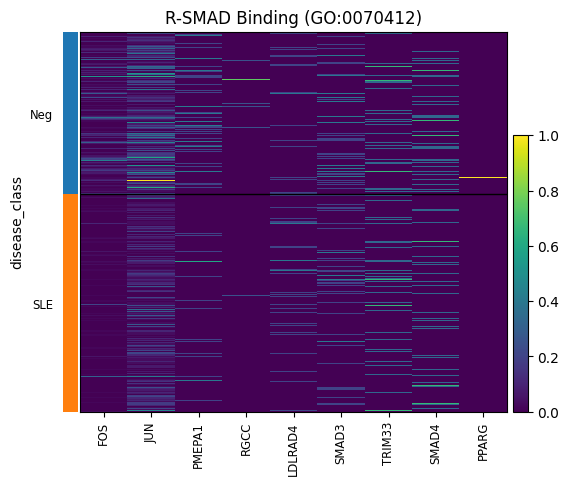

In [23]:
g = sc.pl.heatmap(
    naive_b,
    var_names = gs.res2d.Lead_genes.iloc[0].split(";"),
    standard_scale="var",
    groupby="disease_class",
    figsize=(6,5),
    show=False,
)
g['heatmap_ax'].set_title(gs.res2d.Term.iloc[0])

In [24]:
g

{'heatmap_ax': <Axes: title={'center': 'R-SMAD Binding (GO:0070412)'}>,
 'groupby_ax': <Axes: ylabel='disease_class'>}

In [25]:
gs.res2d

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,gsea,R-SMAD Binding (GO:0070412),-0.847439,-2.495658,0.0,0.0,0.0,9/16,7.58%,FOS;JUN;PMEPA1;RGCC;LDLRAD4;SMAD3;TRIM33;SMAD4...
1,gsea,Transcription Regulatory Region Nucleic Acid B...,-0.514857,-2.401654,0.0,0.0,0.0,47/141,20.30%,FOS;JUND;JUN;ARID5A;EGR1;HNRNPL;PER1;KLF4;HMGB...
2,gsea,Oxidoreduction-Driven Active Transmembrane Tra...,0.640043,2.399358,0.0,0.0,0.0,26/50,15.24%,NDUFA3;NDUFB1;NDUFB3;COX5A;CYB5A;NDUFA1;UQCR10...
3,gsea,mRNA Binding (GO:0003729),-0.531691,-2.398088,0.0,0.0,0.0,102/230,26.33%,PABPC1;RPS3A;RPS5;ZFP36;AGO2;RPS2;RPS3;RPS26;S...
4,gsea,NADH Dehydrogenase (Ubiquinone) Activity (GO:0...,0.670533,2.386175,0.0,0.0,0.0,17/33,11.85%,NDUFA3;NDUFB1;NDUFB3;NDUFC2;NDUFC1;NDUFB7;NDUF...
...,...,...,...,...,...,...,...,...,...,...
335,gsea,Lysine-Acetylated Histone Binding (GO:0070577),0.179799,0.549422,0.977459,1.0,1.0,20/20,95.51%,YEATS4;BRD7;ZMYND8;BRD3;DPF2;THAP7;CARM1;MLLT3...
336,gsea,Acetylation-Dependent Protein Binding (GO:0140...,0.179799,0.549422,0.977459,1.0,1.0,20/20,95.51%,YEATS4;BRD7;ZMYND8;BRD3;DPF2;THAP7;CARM1;MLLT3...
337,gsea,Potassium Channel Activity (GO:0005267),0.181792,0.527825,0.996448,1.0,1.0,21/21,91.27%,KCNH8;PKD2;CCDC51;KCNMA1;KCNK6;KCNC4;TMEM38A;K...
338,gsea,NADP Binding (GO:0050661),0.159519,0.526831,0.994318,1.0,1.0,25/25,97.59%,DECR1;CRYZ;ME3;DHFR;GRHPR;DUS2;QDPR;GMDS;HSD17...


In [26]:
top_x_pathways = 5

In [27]:
# for i in gs.res2d.iterrows():
term_gene_dict = {x[1]["Term"]: x[1]["Lead_genes"].split(";") for i, x in enumerate(gs.res2d.iterrows()) if i < top_x_pathways}

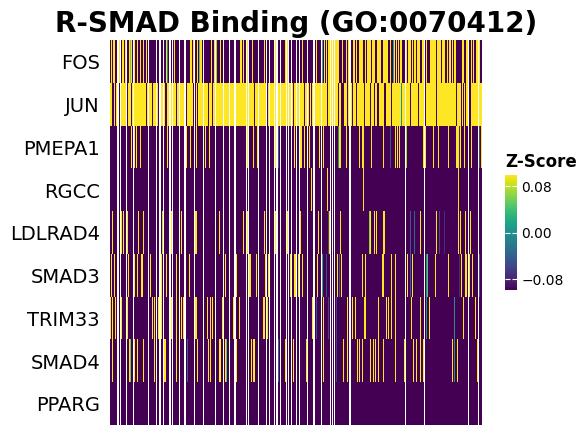

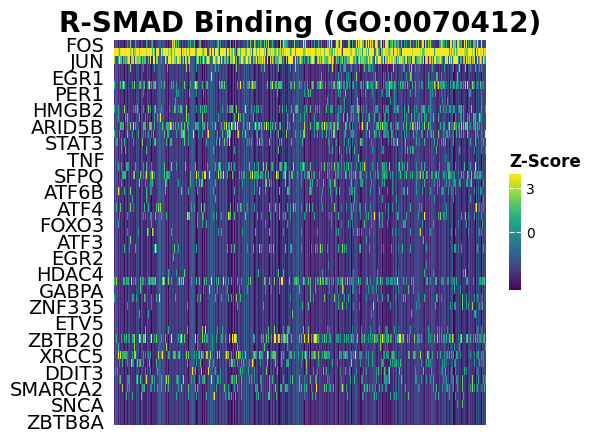

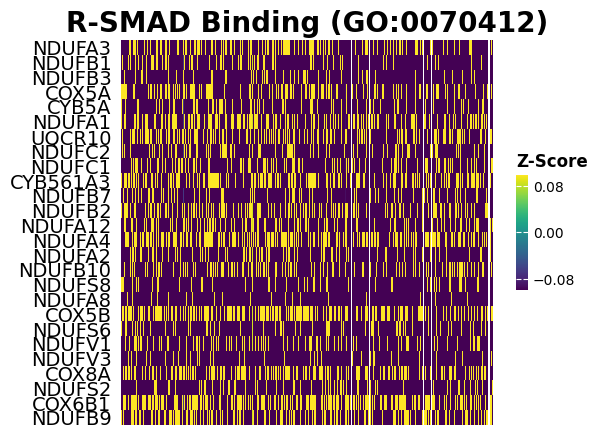

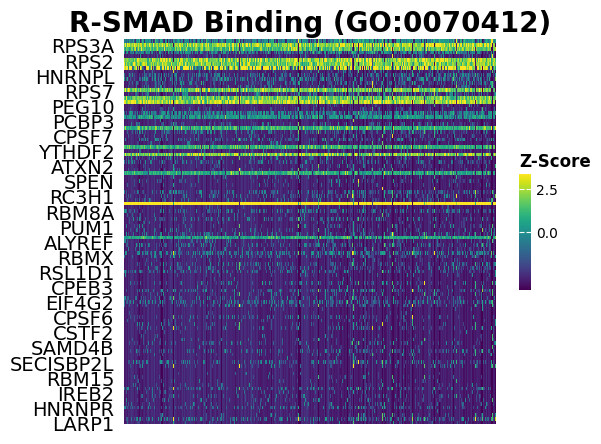

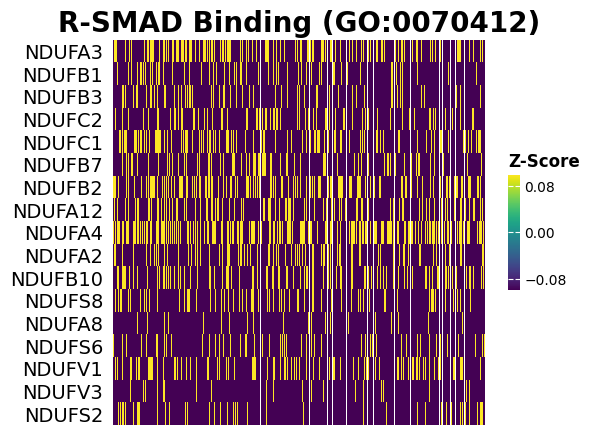

In [28]:
for i in range(5):
    genes = gs.res2d.Lead_genes.iloc[i].split(";")
    ax = gp.heatmap(
        df=gs.heatmat.loc[genes],
        z_score=1,
        title=gs.res2d.Term.iloc[0],
        figsize=(6, 5),
        cmap=plt.cm.viridis,
        xticklabels=False,
        # ofname=str(outdir_path) + "/Heatmap.png",
    )

In [29]:
term_gene_dict.keys()

dict_keys(['R-SMAD Binding (GO:0070412)', 'Transcription Regulatory Region Nucleic Acid Binding (GO:0001067)', 'Oxidoreduction-Driven Active Transmembrane Transporter Activity (GO:0015453)', 'mRNA Binding (GO:0003729)', 'NADH Dehydrogenase (Ubiquinone) Activity (GO:0008137)'])

In [30]:
16/56

0.2857142857142857

In [31]:
from itertools import chain

In [32]:
import more_itertools as mi

In [33]:
len(list(mi.collapse(term_gene_dict.values()[:2])))*0.3

TypeError: 'dict_values' object is not subscriptable

In [ ]:
len(term_gene_dict['R-SMAD Binding (GO:0070412)'] + term_gene_dict['Transcription Regulatory Region Nucleic Acid Binding (GO:0001067)'])

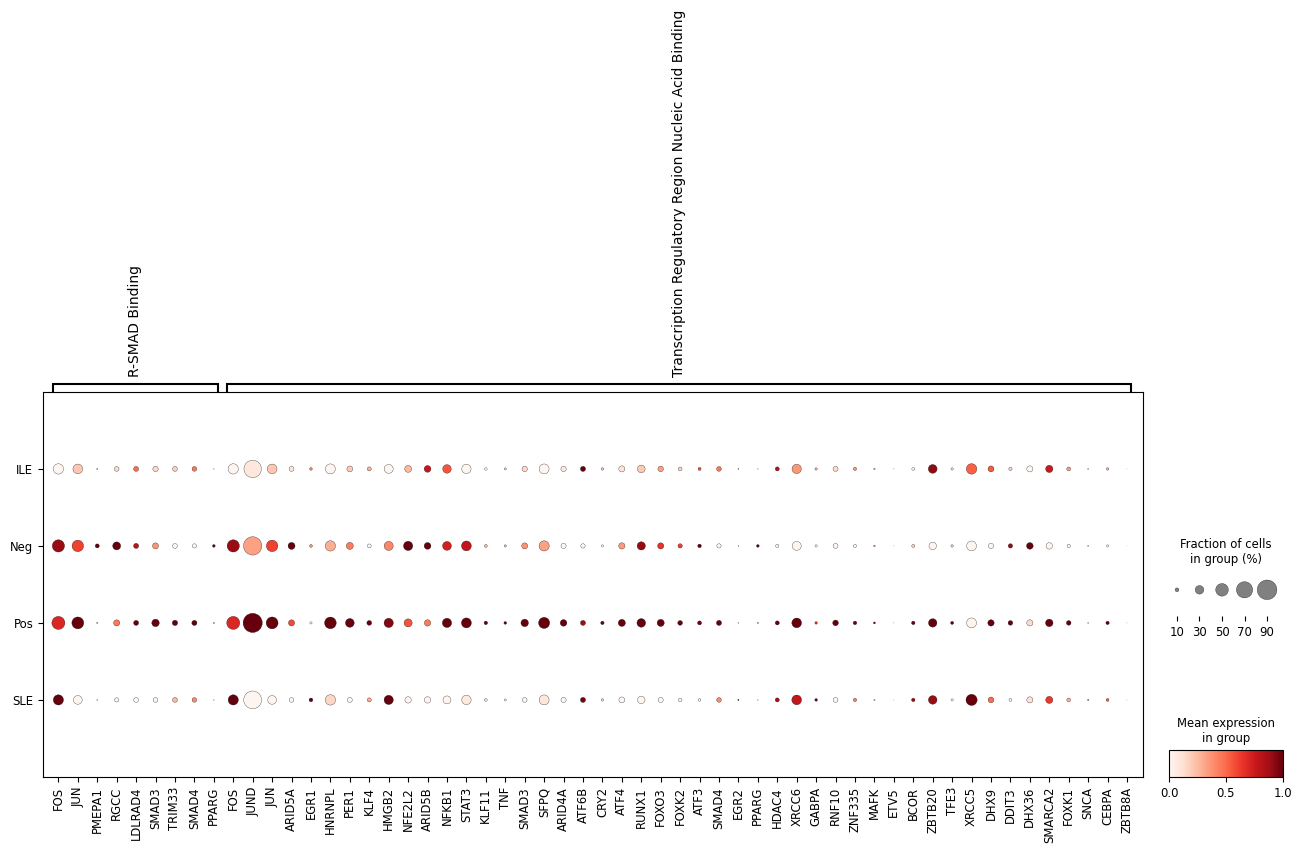

In [34]:
g = sc.pl.dotplot(
    adata=adata,
    var_names={"R-SMAD Binding": term_gene_dict['R-SMAD Binding (GO:0070412)'], "Transcription Regulatory Region Nucleic Acid Binding": term_gene_dict['Transcription Regulatory Region Nucleic Acid Binding (GO:0001067)']},
    standard_scale="var",
    groupby="disease_class",
    figsize=(16,5),
    show=False,
    # show_gene_labels=True,
)

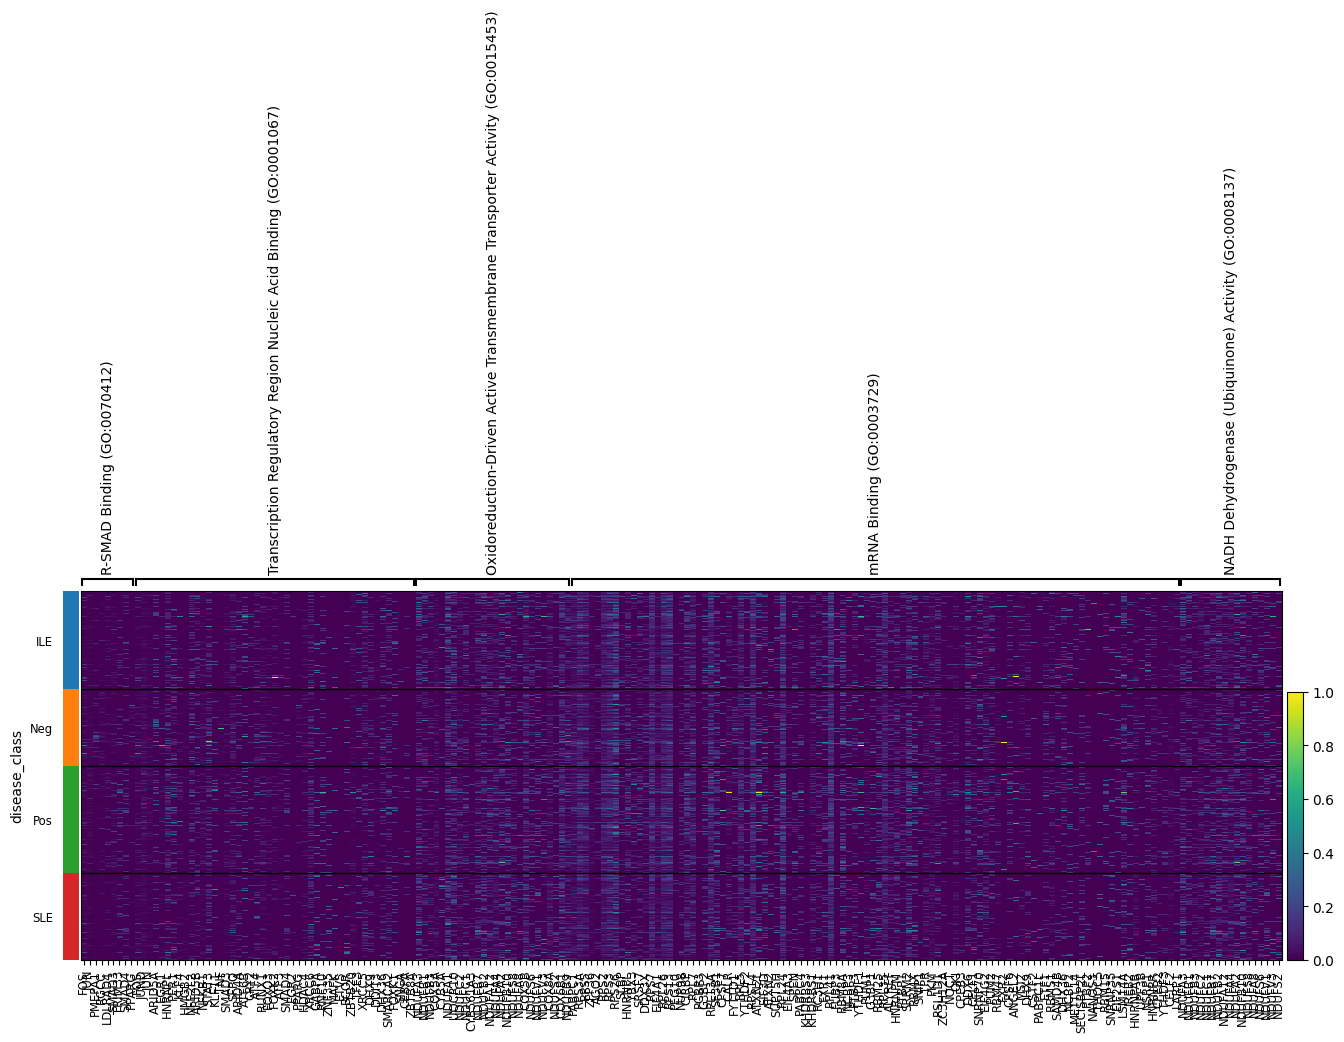

In [35]:
g = sc.pl.heatmap(
    adata=adata,
    var_names=term_gene_dict,
    standard_scale="var",
    groupby="disease_class",
    figsize=(16,5),
    show=False,
    show_gene_labels=True,
    # save=str(outdir_path.joinpath(f"{gs.res2d.Term.iloc[i].str.replace(pat=r'\s\(GO:[0-9]+\)', repl='', regex=True)}_Heatmap.png"))
)
# g["heatmap_ax"].set_title(gs.res2d.Term.iloc[i])

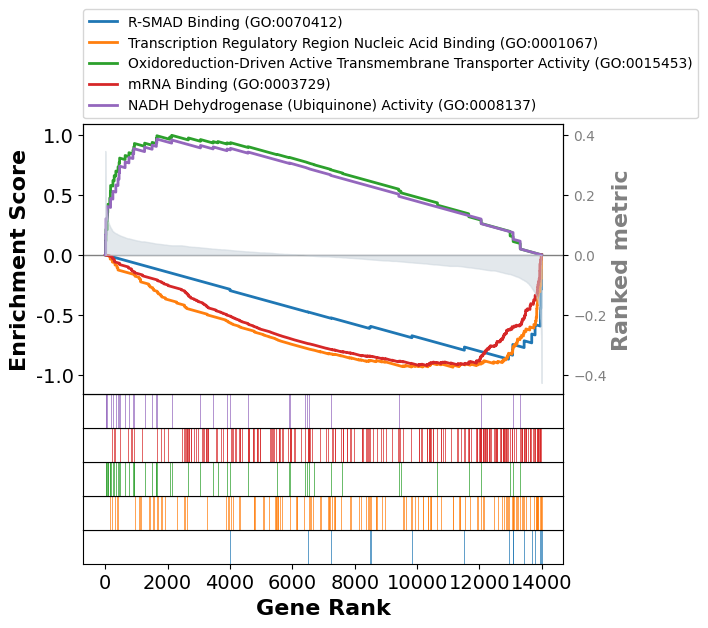

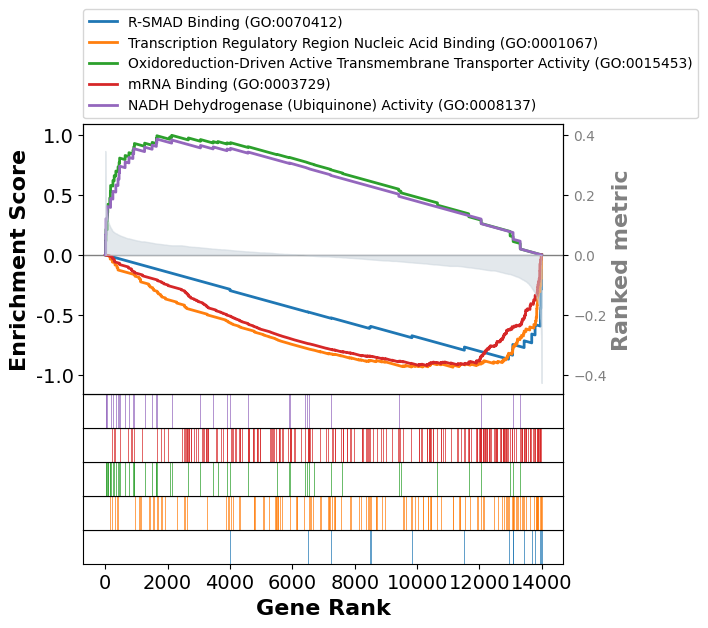

In [36]:
# renamed_term = gs.res2d.Term.iloc[i].str.replace(pat=r'\s\(GO:[0-9]+\)', repl='', regex=True)
gs.plot(terms=gs.res2d.Term[:5])#, ofname=str(outdir_path.joinpath(f"{renamed_term}_Terms.png")))

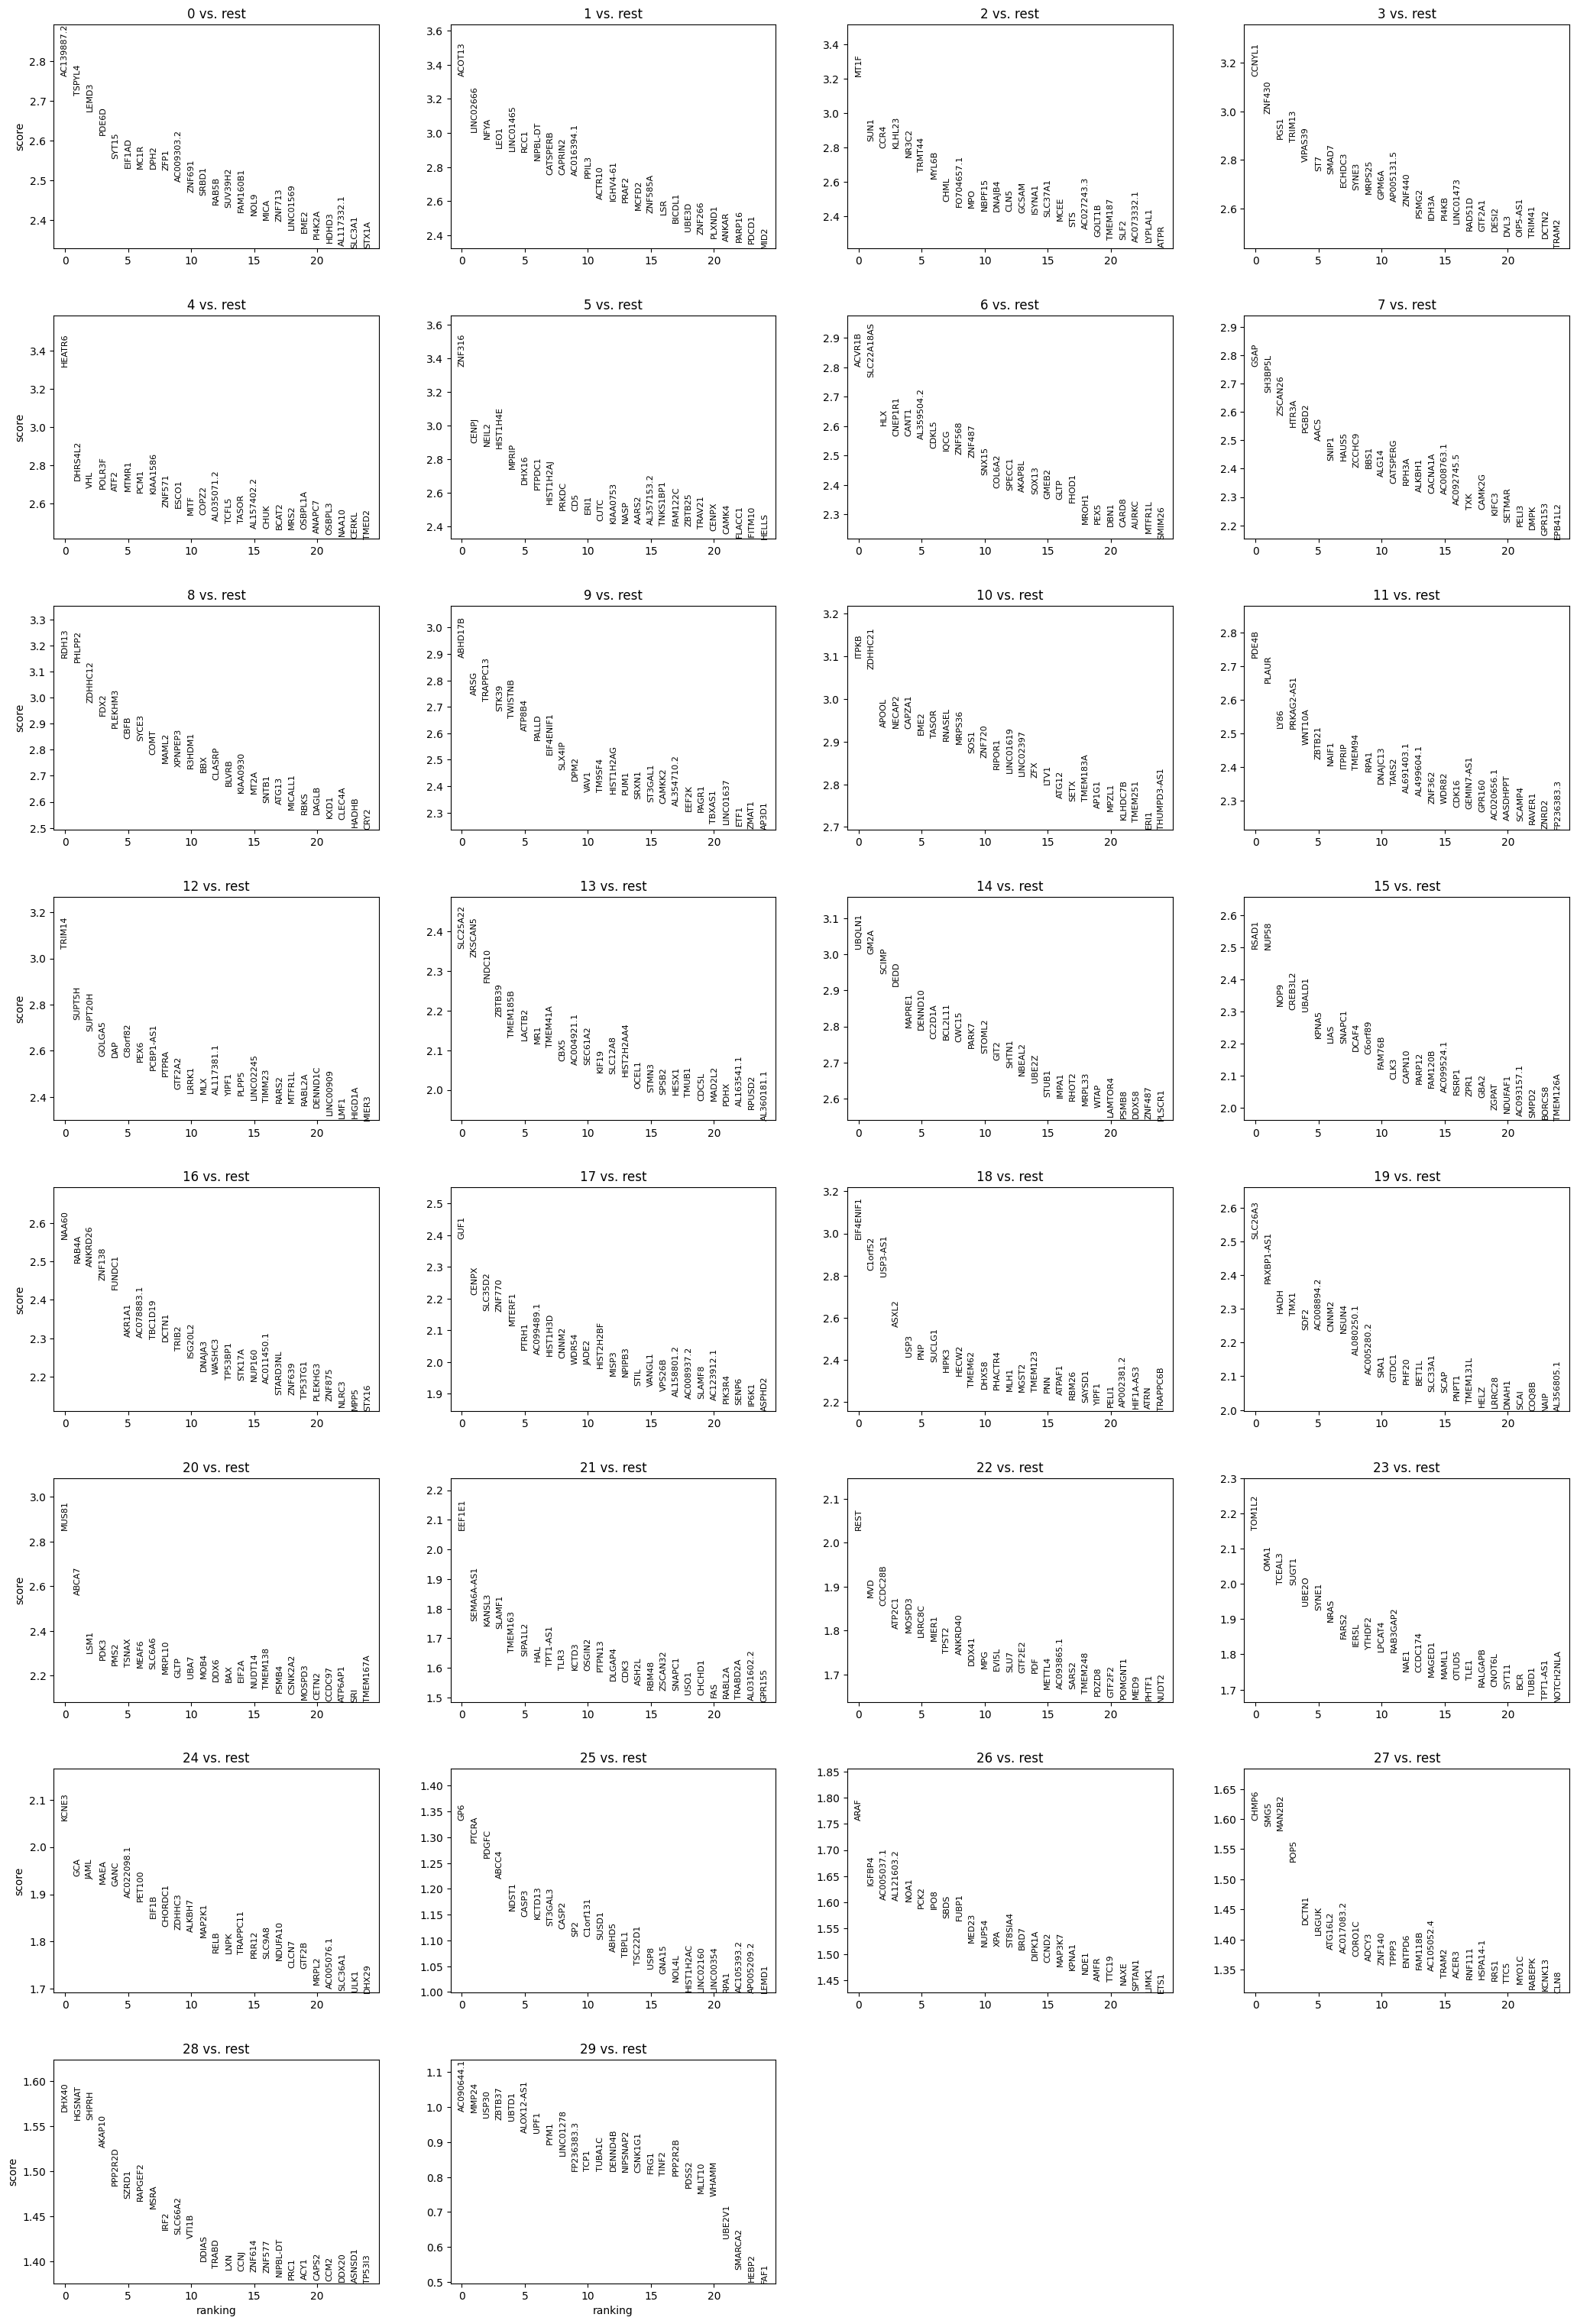

In [37]:
sc.pl.rank_genes_groups(naive_b, n_genes=25, sharey=False)

In [38]:
if ("rank_genes_groups" not in naive_b.uns) or (naive_b.uns["rank_genes_groups"]["params"]["groupby"] != groupby):
        sc.tl.rank_genes_groups(naive_b, groupby=groupby, reference=referencegroup,layer="lognorm", use_raw=True)

/home/milo/workspace/easyGSEApy/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [66]:
naive_b.layers['lognorm'] = np.add(naive_b.layers['lognorm'], 1)

In [67]:
sc.tl.rank_genes_groups(naive_b, groupby="disease_class", layer="lognorm", use_raw=False)

In [57]:
MAX_PVAL = 0.05

In [69]:
degs = sc.get.rank_genes_groups_df(naive_b, group=wanted_group)

In [70]:
degs

,names,scores,logfoldchanges,pvals,pvals_adj
0,IFITM1,18.126892,1.946329,2.622396e-67,3.826076e-63
1,IFI44L,15.568809,1.560401,1.094002e-50,5.320497e-47
2,TCL1A,15.233250,1.759385,2.848035e-48,1.038821e-44
3,XAF1,13.671519,1.420141,1.918201e-40,3.998079e-37
4,CD79B,13.202941,1.516232,1.626995e-37,2.967232e-34
...,...,...,...,...,...
14585,SNX9,-11.531816,-1.244061,1.666865e-29,2.210869e-26
14586,IER2,-12.297181,-1.301492,3.050232e-33,4.450288e-30
14587,EZR,-14.567260,-1.487043,2.222088e-45,6.484054e-42
14588,SLC2A3,-14.749261,-1.621984,3.152040e-45,7.664710e-42


In [71]:
degs_sig = degs[degs["pvals_adj"] < MAX_PVAL]
degs_up = degs_sig[degs_sig["logfoldchanges"] > 0]
degs_dw = degs_sig[degs_sig["logfoldchanges"] < 0]

In [42]:
from tenacity import retry, stop_after_attempt, wait_fixed

In [79]:
@retry(stop=stop_after_attempt(10), wait=wait_fixed(2))
def get_enrichr(gene_list, gene_sets, outdir):
    try:    
        return gp.enrichr(degs_up["names"], gene_sets=geneset, outdir=None)
    except:
        raise Exception

In [80]:
enr_up = get_enrichr(degs_up["names"], gene_sets=geneset, outdir=None)

In [81]:
enr_up.res2d.Term

0      Oxidoreduction-Driven Active Transmembrane Tra...
1                               RNA Binding (GO:0003723)
2      NADH Dehydrogenase (Ubiquinone) Activity (GO:0...
3      NADH Dehydrogenase (Quinone) Activity (GO:0050...
4       Ubiquitin Ligase Inhibitor Activity (GO:1990948)
                             ...                        
313    Protein Serine/Threonine Kinase Activity (GO:0...
314     G Protein-Coupled Receptor Activity (GO:0004930)
315    Cis-Regulatory Region Sequence-Specific DNA Bi...
316    RNA Polymerase II Cis-Regulatory Region Sequen...
317    RNA Polymerase II Transcription Regulatory Reg...
Name: Term, Length: 318, dtype: object

In [128]:
enr_up.res2d.Term.str.replace(pat=r"\s\(GO:[0-9]+\)", repl="", regex=True)

0      Oxidoreduction-Driven Active Transmembrane Tra...
1                                            RNA Binding
2               NADH Dehydrogenase (Ubiquinone) Activity
3                  NADH Dehydrogenase (Quinone) Activity
4                    Ubiquitin Ligase Inhibitor Activity
                             ...                        
320             Protein Serine/Threonine Kinase Activity
321                  G Protein-Coupled Receptor Activity
322    Cis-Regulatory Region Sequence-Specific DNA Bi...
323    RNA Polymerase II Cis-Regulatory Region Sequen...
324    RNA Polymerase II Transcription Regulatory Reg...
Name: Term, Length: 325, dtype: object

In [125]:
enr_up.res2d.Term

0      Oxidoreduction-Driven Active Transmembrane Tra...
1                               RNA Binding (GO:0003723)
2      NADH Dehydrogenase (Ubiquinone) Activity (GO:0...
3      NADH Dehydrogenase (Quinone) Activity (GO:0050...
4       Ubiquitin Ligase Inhibitor Activity (GO:1990948)
                             ...                        
320    Protein Serine/Threonine Kinase Activity (GO:0...
321     G Protein-Coupled Receptor Activity (GO:0004930)
322    Cis-Regulatory Region Sequence-Specific DNA Bi...
323    RNA Polymerase II Cis-Regulatory Region Sequen...
324    RNA Polymerase II Transcription Regulatory Reg...
Name: Term, Length: 325, dtype: object

In [136]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Molecular_Function_2023,Oxidoreduction-Driven Active Transmembrane Tra...,15/54,6.089379e-13,1.979048e-10,0,0,17.210656,484.085166,CYB5A;NDUFB7;NDUFA12;NDUFA3;NDUFB3;NDUFB2;NDUF...
1,GO_Molecular_Function_2023,RNA Binding (GO:0003723),66/1411,1.203790e-08,1.956158e-06,0,0,2.320212,42.309552,RPL5;RPL30;RPL32;RPL34;MRPS12;DDX60L;MRPL37;IF...
2,GO_Molecular_Function_2023,NADH Dehydrogenase (Ubiquinone) Activity (GO:0...,8/33,5.317530e-07,5.539213e-05,0,0,14.103115,203.748928,NDUFB7;NDUFA12;NDUFA3;NDUFB3;NDUFB2;NDUFB1;NDU...
3,GO_Molecular_Function_2023,NADH Dehydrogenase (Quinone) Activity (GO:0050...,8/34,6.817493e-07,5.539213e-05,0,0,13.559993,192.532970,NDUFB7;NDUFA12;NDUFA3;NDUFB3;NDUFB2;NDUFB1;NDU...
4,GO_Molecular_Function_2023,Ubiquitin Ligase Inhibitor Activity (GO:1990948),4/7,8.461923e-06,5.500250e-04,0,0,58.302759,680.972384,RPS15;RPL5;RPS7;RPL37
...,...,...,...,...,...,...,...,...,...,...
320,GO_Molecular_Function_2023,Protein Serine/Threonine Kinase Activity (GO:0...,2/342,9.965418e-01,9.995265e-01,0,0,0.251657,0.000872,EIF2AK2;HTATIP2
321,GO_Molecular_Function_2023,G Protein-Coupled Receptor Activity (GO:0004930),1/250,9.967770e-01,9.995265e-01,0,0,0.172245,0.000556,P2RY14
322,GO_Molecular_Function_2023,Cis-Regulatory Region Sequence-Specific DNA Bi...,13/1098,9.972960e-01,9.995265e-01,0,0,0.505086,0.001368,MEF2C;STAT1;CCDC106;ETS1;KLF2;THAP11;SPIB;HHEX...
323,GO_Molecular_Function_2023,RNA Polymerase II Cis-Regulatory Region Sequen...,13/1122,9.980343e-01,9.995265e-01,0,0,0.493513,0.000971,MEF2C;STAT1;CCDC106;ETS1;KLF2;THAP11;SPIB;HHEX...


In [135]:
enr_up.res2d["Genes"].iloc[0].split(";")

['CYB5A',
 'NDUFB7',
 'NDUFA12',
 'NDUFA3',
 'NDUFB3',
 'NDUFB2',
 'NDUFA1',
 'NDUFC2',
 'NDUFB1',
 'NDUFC1',
 'CYB561A3',
 'UQCR10',
 'COX5B',
 'COX7C',
 'COX5A']

In [140]:
dir(enr_up)

['ENRICHR_URL',
 'ENRICHR_URL_SPEED',
 '_Enrichr__gs2dict',
 '_Enrichr__no_plot',
 '_Enrichr__parse_gmt',
 '_Enrichr__top_term',
 '__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_bg',
 '_gls',
 '_gs',
 '_gs_name',
 '_is_entrez_id',
 '_isezid',
 '_logger',
 '_organism',
 '_outdir',
 'background',
 'check_genes',
 'cutoff',
 'descriptions',
 'enrich',
 'figsize',
 'filter_gmt',
 'format',
 'gene_list',
 'gene_sets',
 'get_background',
 'get_libraries',
 'get_results',
 'get_results_with_background',
 'module',
 'organism',
 'outdir',
 'parse_background',
 'parse_genelists',
 'parse_genesets',
 'prepare_outdir',
 'res2d',
 'results',
 'run',
 'send_background'

In [147]:
from rich.progress import track

<Axes: title={'center': 'Oxidoreduction-Driven Active Transmembrane Transporter Activity (GO:0015453)'}>

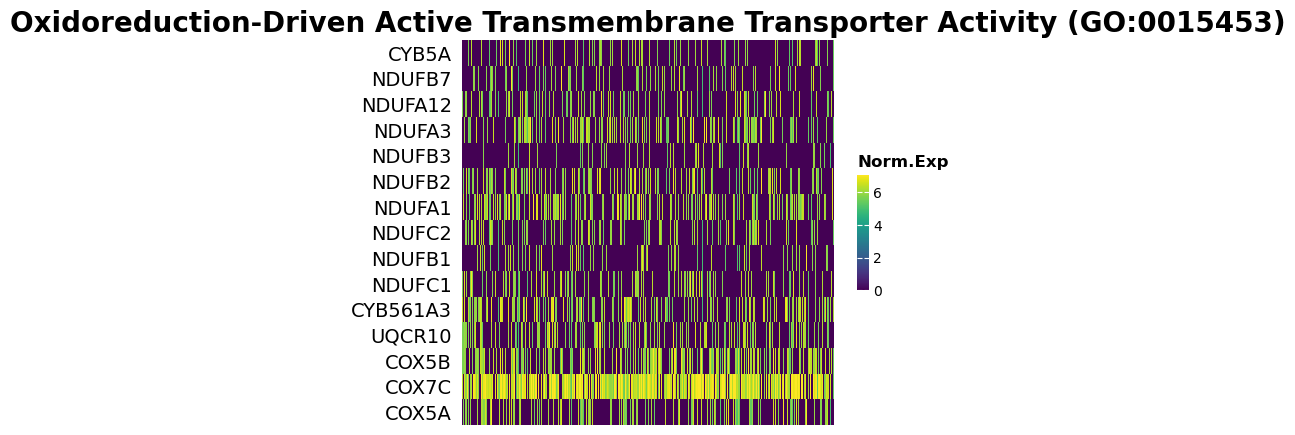

In [149]:
i = 0
gp.heatmap(
    df=sc.get.obs_df(naive_b, keys=enr_up.res2d["Genes"].iloc[i].split(";")).transpose(),
    z_score=None,
    title=enr_up.res2d["Term"].iloc[i],
    figsize=(6, 5),
    cmap=plt.cm.viridis,
    xticklabels=False,
    # ofname=str(outdir_path.joinpath(f"{enr_up.res2d.Term.iloc[i].str.replace(pat=r'\s\(GO:[0-9]+\)', repl='', regex=True)}_Heatmap.png")),
)

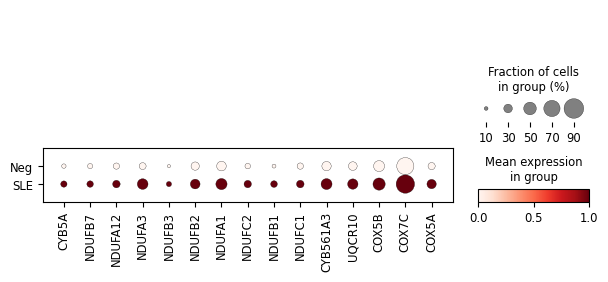

In [151]:
sc.pl.dotplot(naive_b, var_names=enr_up.res2d["Genes"].iloc[i].split(";"), groupby="disease_class", standard_scale="var")

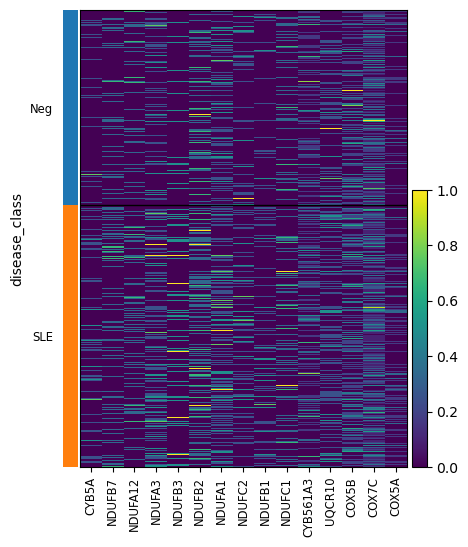

In [152]:
sc.pl.heatmap(naive_b, var_names=enr_up.res2d["Genes"].iloc[i].split(";"), groupby="disease_class", standard_scale="var")

In [88]:
enr_up.res2d.Term

0      Oxidoreduction-Driven Active Transmembrane Tra...
1                               RNA Binding (GO:0003723)
2      NADH Dehydrogenase (Ubiquinone) Activity (GO:0...
3      NADH Dehydrogenase (Quinone) Activity (GO:0050...
4       Ubiquitin Ligase Inhibitor Activity (GO:1990948)
                             ...                        
313    Protein Serine/Threonine Kinase Activity (GO:0...
314     G Protein-Coupled Receptor Activity (GO:0004930)
315    Cis-Regulatory Region Sequence-Specific DNA Bi...
316    RNA Polymerase II Cis-Regulatory Region Sequen...
317    RNA Polymerase II Transcription Regulatory Reg...
Name: Term, Length: 318, dtype: object

In [89]:
enr_up.res2d.Term = enr_up.res2d.Term.str.replace(pat=r"\s\(GO:[0-9]+\)", repl="", regex=True)

<Axes: title={'center': 'Up'}, xlabel='Combined Score'>

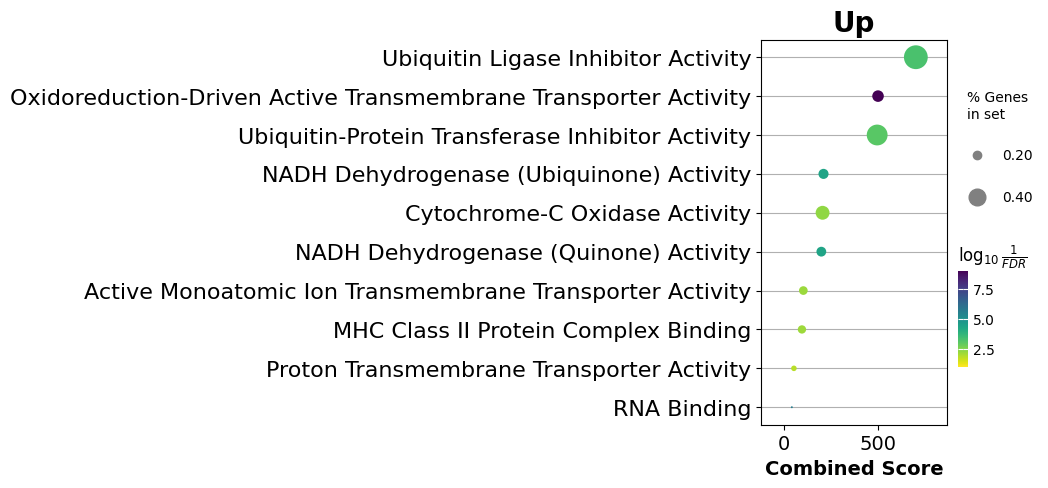

In [92]:
gp.dotplot(enr_up.res2d, figsize=(3, 5), title="Up",)# cmap=plt.cm.autumn_r)

In [93]:
plt.get_fignums()

[]

In [94]:
fig1 = plt.gcf()

<Figure size 640x480 with 0 Axes>

In [95]:
plt.get_fignums()

[]

In [96]:
from gseapy.scipalette import SciPalette
sci = SciPalette()

In [100]:
degs_down = degs_dw

In [110]:
degs_down["names"].shape[0]

636

In [109]:
pd.Series().shape == (0,)

True

In [115]:
type(enr_up)

gseapy.enrichr.Enrichr

In [122]:
gp.Enrichr(gene_list=[], gene_sets=geneset).res2d is None

True

In [101]:
enr_down = gp.enrichr(degs_down.names, gene_sets=geneset, outdir=str(outdir_path))

In [ ]:
enr_down.res2d.Term = enr_down.res2d.Term.str.replace(pat=r"\s\(GO:[0-9]+\)", repl="", regex=True)

In [123]:
    sci = SciPalette()
    NbDr = sci.create_colormap()

In [125]:
type(NbDr)

matplotlib.colors.LinearSegmentedColormap

In [127]:
from matplotlib import colormaps

In [129]:
type(colormaps['viridis'])

matplotlib.colors.ListedColormap

In [130]:
nodes, edges = gp.enrichment_map(gs.res2d)

In [131]:
G = nx.from_pandas_edgelist(
        edges, source="src_idx", target="targ_idx", edge_attr=["jaccard_coef", "overlap_coef", "overlap_genes"]
    )

In [132]:
G

In [133]:
for node in nodes.index:
        if node not in G.nodes():
            G.add_node(node)

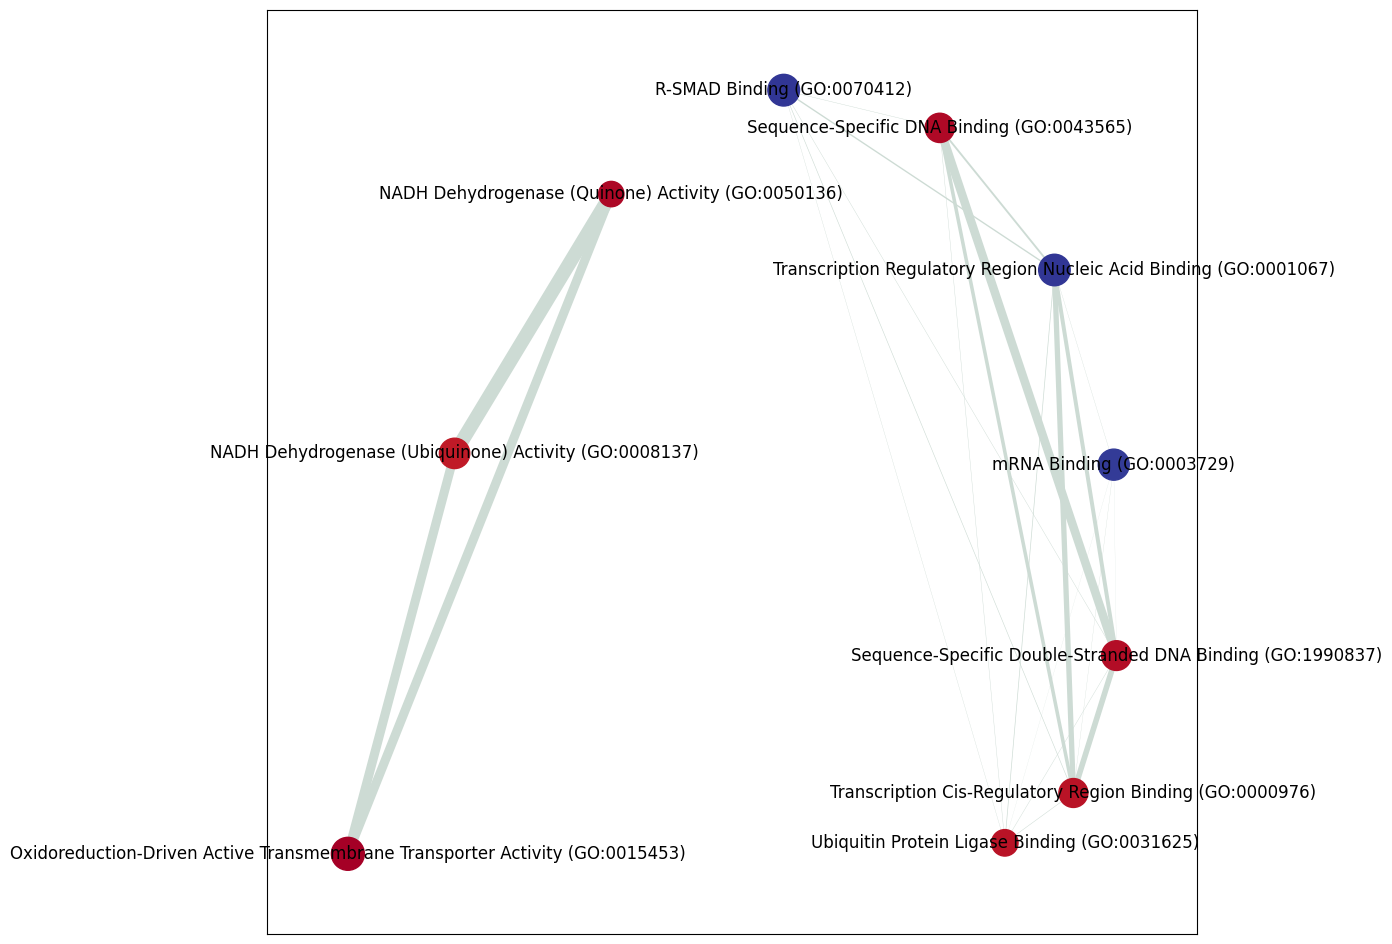

In [135]:
fig, ax = plt.subplots(figsize=(12, 12))
pos = nx.layout.spiral_layout(G)
nx.draw_networkx_nodes(
    G, pos=pos, cmap=plt.cm.RdYlBu, node_color=list(nodes.NES), node_size=list(nodes.Hits_ratio * 1000), ax=ax
)
# draw node label
nx.draw_networkx_labels(G, pos=pos, labels=nodes.Term.to_dict(), clip_on=False, ax=ax)
# draw edge
edge_weight = nx.get_edge_attributes(G, "jaccard_coef").values()
nx.draw_networkx_edges(G, pos=pos, width=[x * 10 for x in edge_weight], edge_color="#CDDBD4", ax=ax)

#### Create First Cartesian Product

In [59]:
import itertools
comparisons=[x for x in itertools.combinations_with_replacement(rna_only.obs['disease_class'].unique().tolist(),2)]

In [60]:
nodupes=[]
for x in comparisons:
    if x[0]!=x[1]:
        nodupes.append(x)

In [61]:
nodupes

[('ILE', 'Neg'),
 ('ILE', 'SLE'),
 ('ILE', 'Pos'),
 ('Neg', 'SLE'),
 ('Neg', 'Pos'),
 ('SLE', 'Pos')]

#### Format Cell types

In [62]:
cell_labels_nospace=[x.replace(" ","_") for x in rna_only.obs["type_label"].unique().tolist()]
formatted_cell_labels=[x.replace("/","_") for x in cell_labels_nospace]
formatted_cell_labels

['CC2',
 'CD8+_CD27+',
 'CC4',
 'Nonclassical_monocytes',
 'CC6',
 'CD56+_CD52+',
 'Activated_B_Naive',
 'Macrophages',
 'CC3',
 'KIR3DL1+',
 'Memory',
 'CD4+_CD27-_effector',
 'NKT',
 'CD4+_CD27+',
 'GZMK+',
 'Gamma_delta',
 'IC4',
 'Myeloid_derived_suppressor_cells',
 'MAIT',
 'ILC1',
 'Transitional',
 'CD14+_CD11c+_monocytes',
 'CD4+_Regulatory',
 'CD4+_S100a+',
 'ABCs',
 'CD8+_Tcm_Naive_cytotoxic',
 'CD1c-CD141-_monocyte-like_DC',
 'CD4+_Naive_Helper',
 'Plasma_cells',
 'IC2',
 'Double-negative',
 'ILC3',
 'IC3',
 'CC1',
 'IC1',
 'CC5',
 'CD14+CD64+_CD16-_monocytes',
 'CD8+_Naive',
 'CD4+_Memory',
 'CD56dim',
 'CD56+',
 'Undefined',
 'Naive']

#### Final Cartesian Product to capture all combinations

In [63]:
all_comps=[x for x in itertools.product(nodupes,formatted_cell_labels)]

In [64]:
all_comps

[(('ILE', 'Neg'), 'CC2'),
 (('ILE', 'Neg'), 'CD8+_CD27+'),
 (('ILE', 'Neg'), 'CC4'),
 (('ILE', 'Neg'), 'Nonclassical_monocytes'),
 (('ILE', 'Neg'), 'CC6'),
 (('ILE', 'Neg'), 'CD56+_CD52+'),
 (('ILE', 'Neg'), 'Activated_B_Naive'),
 (('ILE', 'Neg'), 'Macrophages'),
 (('ILE', 'Neg'), 'CC3'),
 (('ILE', 'Neg'), 'KIR3DL1+'),
 (('ILE', 'Neg'), 'Memory'),
 (('ILE', 'Neg'), 'CD4+_CD27-_effector'),
 (('ILE', 'Neg'), 'NKT'),
 (('ILE', 'Neg'), 'CD4+_CD27+'),
 (('ILE', 'Neg'), 'GZMK+'),
 (('ILE', 'Neg'), 'Gamma_delta'),
 (('ILE', 'Neg'), 'IC4'),
 (('ILE', 'Neg'), 'Myeloid_derived_suppressor_cells'),
 (('ILE', 'Neg'), 'MAIT'),
 (('ILE', 'Neg'), 'ILC1'),
 (('ILE', 'Neg'), 'Transitional'),
 (('ILE', 'Neg'), 'CD14+_CD11c+_monocytes'),
 (('ILE', 'Neg'), 'CD4+_Regulatory'),
 (('ILE', 'Neg'), 'CD4+_S100a+'),
 (('ILE', 'Neg'), 'ABCs'),
 (('ILE', 'Neg'), 'CD8+_Tcm_Naive_cytotoxic'),
 (('ILE', 'Neg'), 'CD1c-CD141-_monocyte-like_DC'),
 (('ILE', 'Neg'), 'CD4+_Naive_Helper'),
 (('ILE', 'Neg'), 'Plasma_cells'),


#### Create paths prior to final loop

In [50]:
import os 

In [51]:
pamfolder=os.getcwd()

In [52]:
pamfolder

'/home/nemo/workspace/PAM'

In [53]:
path = os.path.join(pamfolder, "GSEA")

#### Performing all Comparisons in one loop

In [ ]:
from rich.progress import track

In [ ]:
for combination in track(all_comps):
    # Capture the current cell type 
    current_cluster=combination[1]
    rowarray=np.array(((rna_only.obs["disease_class"]==combination[0][0])|(filtered_Raw_Counts.obs["disease_class"]==combination[0][1]))&
                      (filtered_Raw_Counts.obs["Manual Annotation"]==current_cluster))
    columnarray= ((~np.array(filtered_Raw_Counts.var_names.str.startswith("MT-")))&
                  (~np.array(filtered_Raw_Counts.var_names.str.startswith("RP"))))
    groupbycolumn="disease_class"
    current_referencegroup=combination[0][1]
    geneset_choice=["GO_Biological_Process_2023","Human_Gene_Atlas","WikiPathways_2019_Human","KEGG_2021_Human","GO_Cellular_Component_2023","GO_Molecular_Function_2023"]
    group_of_interest=combination[0][0]
    try:
        os.mkdir(os.path.join(path, current_cluster))
    except FileExistsError:
        print(current_cluster+" Directory already exists")
    try:
        os.mkdir(os.path.join(path, current_cluster,group_of_interest+"vs"+current_referencegroup))
    except FileExistsError:
        print(os.path.join(path, current_cluster,group_of_interest+"vs"+current_referencegroup)+" Directory already exists")
    saveloc=os.path.join(path, current_cluster,group_of_interest+"vs"+current_referencegroup)
    res, nodes, edges = GSEApy_process(dataframe=rna_only, 
                   rowbool=rowarray, 
                   columnbool=columnarray,
                   groupby=groupbycolumn,
                   referencegroup=current_referencegroup, 
                   geneset=geneset_choice,
                   Wanted_Group=group_of_interest,
                   outdir_path=saveloc)

----

In [141]:
wanted_group = None

In [146]:
any([True if _ is None else False for _ in [groupby, referencegroup, geneset, wanted_group, outdir_path]])

True

In [143]:
groupby, referencegroup, geneset, wanted_group, outdir_path

('disease_class', 'Neg', 'GO_Molecular_Function_2023', None, 'testing_output')

In [153]:
def stuff(bob, carl, doug):
    things = locals()
    print(things)

In [154]:
stuff("a", "b", "c")

{'bob': 'a', 'carl': 'b', 'doug': 'c'}


In [161]:
logger.info(f"{len(var_subset)=}")

2024-08-09 10:43:53.265 | INFO     | __main__:<module>:1 - len(var_subset)=14590


In [248]:
from pathlib import Path
from typing import Final, Literal

import re
import gseapy as gp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import sparse
from anndata import AnnData
from loguru import logger
from matplotlib import colormaps
from scipy.sparse import issparse
from rich.progress import Progress

MAX_PVAL: Final[float] = 0.05

def is_integer_array(arr) -> bool:
    """
    Test if an array is really all integers
    """
    if issparse(arr):
        # have to convert to `sparse.COO` here as `scipy.csr_matrix` either no longer or never did support numpy
        # calculations on it
        return not (np.mod(sparse.asCOO(arr), 1) != 0).any()
    else:
        return not (np.mod(arr, 1) != 0).any()


def GSEApy_process(
    adata: AnnData,
    obs_subset: pd.Series | pd.Index | list[str] | None = None,
    var_subset: pd.Series | pd.Index | list[str] | None = None,
    top_x_pathways: int = 5,
    top_pathway_type: Literal["heatmap", "dotplot"] = "dotplot",
    groupby: str | None = None,
    referencegroup: str | None = None,
    geneset: str | Path | None = None,
    wanted_group: str | None = None,
    outdir_path: Path | None = None,
):
    for _ in ["groupby", "referencegroup", "wanted_group"]:
        if _ is None:
            msg = f"A value for {_} was not given"
            raise SyntaxError(msg)
    if geneset is None:
        geneset = ["GO_Biological_Process_2023", "GO_Cellular_Component_2023","GO_Molecular_Function_2023"]
        logger.info("No geneset was specified. Using the three GeneOntology groups")

    # TODO: no need to repeat normalization/log-transformation. Wrap the next few lines in something like a
    # prep_adata() function
    outdir_path = Path().cwd() if outdir_path is None else outdir_path

    obs_subset = adata.obs_names if obs_subset is None else obs_subset
    var_subset = adata.var_names if var_subset is None else var_subset

    if (len(obs_subset) < adata.shape[0]) or (len(var_subset) < adata.shape[1]):
        logger.info("subsetting anndata obj")
        adata = adata[obs_subset, var_subset].copy()

    if not is_integer_array(adata.X):
        if "counts" in adata.layers and is_integer_array(adata.layers["counts"]):
            adata.layers["lognorm"] = adata.X.copy()
            adata.X = adata.layers["counts"].copy()

            logger.info("normalizing and log transforming data")
            sc.pp.normalize_total(adata, target_sum=1e6)
            sc.pp.log1p(adata)
        else:
            msg = "This function requires starting with untransformed, integer counts."
            raise ValueError(msg)

    adata.layers["lognorm"] = adata.X.copy()

    ####GSEA
    if issparse(adata.layers["counts"]):
        logger.info("inflating sparse counts")
        counts_df = adata.layers["counts"].toarray().transpose()
    else:
        counts_df = adata.layers["counts"].transpose()
    logger.info("Performing GSEA")
    gs = gp.GSEA(
        data=pd.DataFrame(
            counts_df, index=var_subset, columns=obs_subset
        ),  # row -> genes, column-> samples
        gene_sets=geneset,
        classes=adata.obs.loc[obs_subset,groupby].tolist(),
        permutation_num=1000,
        permutation_type="phenotype",
        outdir=str(outdir_path.joinpath("GSEA_results")),
        method="s2n",  # signal_to_noise
        threads=16,
    )
    gs.pheno_pos = wanted_group
    gs.pheno_neg = referencegroup
    gs.run()

    # both sc.pl.heatmap and sc.pl.dotplot let you group variables *IF* you supply the var_names as a dict[str, list[str]]
    # this converts the "Term" and "Lead_genes" columns into a dict for the number of top pathways specified
    term_gene_dict = {
        re.sub(pattern=r"\s\(GO:[0-9]+\)", repl="", string=x[1]["Term"]): x[1]["Lead_genes"].split(";")
        for i, x
        in enumerate(gs.res2d.iterrows())
        if i < top_x_pathways
    }

    with Progress() as progress:
        task = progress.add_task(description="Creating GSEA pathway plots for", total=top_x_pathways)
        progress.start()
        for i in term_gene_dict:
            # term_name = re.sub(pattern=r"\s\(GO:[0-9]+\)", repl="", string=gs.res2d.Term.iloc[i])
            progress.update(task, description=f"Creating GSEA pathway plots for {i}")
            logger.info(f"generating plots for {i}")
            fig, ax = plt.subplots(figsize=(9,5))
            match top_pathway_type:
                case "heatmap":
                    g = sc.pl.heatmap(
                        adata=adata,
                        var_names=term_gene_dict[i],
                        standard_scale="var",
                        groupby="disease_class",
                        # figsize=(9,5), # I don't like this. Replace with user-defined? Return values packaged so that one could rapidly recreate?
                        show=False,
                        ax=ax
                        # save=str(outdir_path.joinpath(f"{i}_Heatmap.png")) # This DOES NOT WORK! WTF? It just reinterprets the path in some weird way. gonna have to make a pull request to scanpy
                    )
                case "dotplot":
                    g = sc.pl.dotplot(
                        adata=adata,
                        var_names=term_gene_dict[i],
                        standard_scale="var",
                        groupby="disease_class",
                        # figsize=(9,5),
                        show=False,
                        # save=str(outdir_path.joinpath(f"{i}_Heatmap.png"))
                        # show_gene_labels=True,
                        ax=ax
                    )
            ax.set_title(i)
            ax.figure.savefig(Path(outdir_path).absolute().joinpath("GSEA_results", f"{i}_Heatmap.png"))
            progress.update(task, advance=1)
        term = gs.res2d.Term
        # gp.gseaplot(res.ranking, term=term[i], **res.results[term[i]])
        gs.plot(terms=term[:top_x_pathways], ofname=str(outdir_path.joinpath("GSEA_results", "Top_GSEA_Terms.png")))

    #### DEG analysis
    if ("rank_genes_groups" not in adata.uns) and (adata.uns["rank_genes_groups"]["params"]["groupby"] != groupby):
        logger.info("Performing DEG analysis")
        sc.tl.rank_genes_groups(adata, groupby=groupby, reference=referencegroup,layer="lognorm", use_raw=False)
    # sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
    degs = sc.get.rank_genes_groups_df(adata, group=wanted_group)
    if np.all(degs["logfoldchanges"] == np.nan): # should this maybe be changed to np.any?
        msg = "There is something wrong with the data. All log fold changes are reported as NAs"
        logger.error(msg)
    else:
        degs_sig = degs[degs["pvals_adj"] < MAX_PVAL]
        degs_up = degs_sig[degs_sig["logfoldchanges"] > 0]
        degs_down = degs_sig[degs_sig["logfoldchanges"] < 0]

    #### Enrichment
    if degs_up.shape[0] > 0:
        logger.info(f"Performing Enrichr analysis of upregulated in {wanted_group} genes")
        enr_up = gp.enrichr(degs_up["names"], gene_sets=geneset, outdir=str(outdir_path.joinpath("Enrichr_results")))
        enr_up.res2d.Term = enr_up.res2d.Term.str.replace(pat=r"\s\(GO:[0-9]+\)", repl="", regex=True)
        try:
            gp.dotplot(enr_up.res2d, figsize=(3, 5), title="Up", cmap=plt.cm.autumn_r)
            fig1 = plt.gcf()
            fig1.savefig(str(outdir_path.joinpath("Enrichr_results", "ORA_UP.png")), bbox_inches="tight")
        except ValueError:
            logger.error("No enrich terms at current cutoff")
    else:
        logger.info(f"No significant upregulated in {wanted_group} genes were found")
        enr_up = gp.Enrichr(gene_list=[], gene_sets=geneset) # make an empty object to prevent errors downstream

    if degs_up.shape[0] > 0:
        logger.info(f"Performing Enrichr analysis of downregulated in {wanted_group} genes")
        enr_down = gp.enrichr(degs_down["names"], gene_sets=geneset, outdir=str(outdir_path.joinpath("Enrichr_results")))
        enr_down.res2d.Term = enr_down.res2d.Term.str.replace(pat=r"\s\(GO:[0-9]+\)", repl="", regex=True)
        try:
            gp.dotplot(enr_down.res2d, figsize=(3, 5), title="Down", cmap=plt.cm.winter_r, size=5, )
            fig1 = plt.gcf()
            fig1.savefig(str(outdir_path.joinpath("Enrichr_results", "ORA_DOWN.png")), bbox_inches="tight")
        except ValueError:
            logger.error("No enrich terms at current cutoff")
    else:
        logger.info(f"No significant downregulated in {wanted_group} genes were found")
        enr_down = gp.Enrichr(gene_list=[], gene_sets=geneset) # make an empty object to prevent errors downstream

    enr_up.res2d["UP_DW"] = "UP"
    enr_down.res2d["UP_DW"] = "DOWN"
    enr_res = pd.concat([enr_up.res2d.head(), enr_down.res2d.head()])

    try:
        ax = gp.dotplot(
            enr_res,
            figsize=(3, 5),
            x="UP_DW",
            x_order=["UP", "DOWN"],
            title="GO_BP",
            cmap=colormaps["viridis"].reversed(),
            size=3,
            show_ring=True,
        )
        ax.set_xlabel("")
        fig1 = plt.gcf()
        fig1.savefig(str(outdir_path.joinpath("Enrichr_results", "ORA_Dotplot.png")), bbox_inches="tight")
    except ValueError:
        logger.error("No enrich terms at current cutoff")
    try:
        ax = gp.barplot(
            enr_res,
            figsize=(3, 5),
            group="UP_DW",
            title="GO_BP",
            color=["b", "r"],
            ofname=str(outdir_path.joinpath("Enrichr_results", "Enriched_Barplot.png")),
        )
    except ValueError:
        logger.error("No enrich terms at current cutoff")

    ##### Network Plot
    nodes, edges = gp.enrichment_map(gs.res2d)
    G = nx.from_pandas_edgelist(
        edges, source="src_idx", target="targ_idx", edge_attr=["jaccard_coef", "overlap_coef", "overlap_genes"]
    )

    # Add missing node if there is any
    for node in nodes.index:
        if node not in G.nodes():
            G.add_node(node)
    fig, ax = plt.subplots(figsize=(12, 12))

    # init node cooridnates
    pos = nx.layout.spiral_layout(G)
    # node_size = nx.get_node_attributes()
    # draw node
    nx.draw_networkx_nodes(
        G, pos=pos, cmap=plt.cm.RdYlBu, node_color=list(nodes.NES), node_size=list(nodes.Hits_ratio * 1000), ax=ax
    )
    # draw node label
    nx.draw_networkx_labels(G, pos=pos, labels=nodes.Term.to_dict(), clip_on=False, ax=ax)
    # draw edge
    edge_weight = nx.get_edge_attributes(G, "jaccard_coef").values()
    nx.draw_networkx_edges(G, pos=pos, width=[x * 10 for x in edge_weight], edge_color="#CDDBD4", ax=ax)
    fig1 = plt.gcf()
    fig1.savefig(str(outdir_path.joinpath("GSEA_results", "Network.png")), bbox_inches="tight")
    nodes.to_csv(str(outdir_path.joinpath("GSEA_results", "Nodes.csv")))
    edges.to_csv(str(outdir_path.joinpath("GSEA_results", "Edges.csv")))


2024-08-09 11:59:52.128 | INFO     | __main__:GSEApy_process:79 - inflating sparse counts
2024-08-09 11:59:52.148 | INFO     | __main__:GSEApy_process:83 - Performing GSEA
2024-08-09 12:01:04.128 | INFO     | __main__:GSEApy_process:115 - generating plots for Regulation Of miRNA Transcription
2024-08-09 12:01:04.204 | INFO     | __main__:GSEApy_process:115 - generating plots for Proton Motive Force-Driven ATP Synthesis
2024-08-09 12:01:04.310 | INFO     | __main__:GSEApy_process:115 - generating plots for Proton Motive Force-Driven Mitochondrial ATP Synthesis
2024-08-09 12:01:04.406 | INFO     | __main__:GSEApy_process:115 - generating plots for Oxidative Phosphorylation
2024-08-09 12:01:04.529 | INFO     | __main__:GSEApy_process:115 - generating plots for Cellular Response To Peptide Hormone Stimulus


2024-08-09 12:01:04.929 | INFO     | __main__:GSEApy_process:164 - Performing Enrichr analysis of upregulated in SLE genes
2024-08-09 12:01:07.454 | INFO     | __main__:GSEApy_process:178 - Performing Enrichr analysis of downregulated in SLE genes


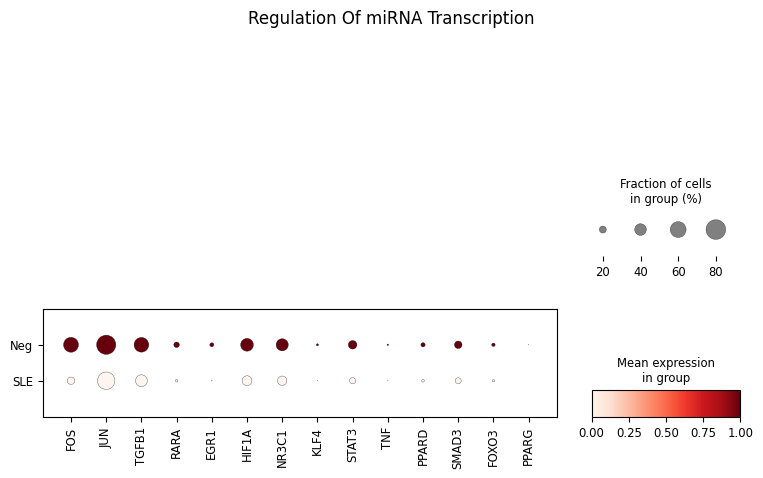

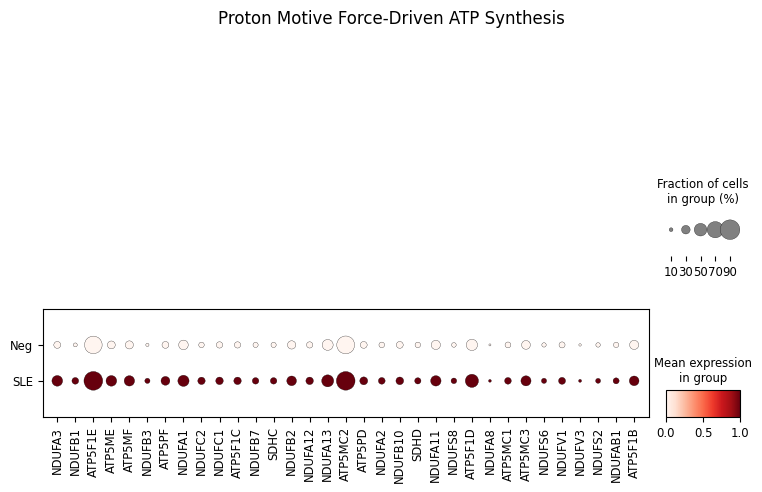

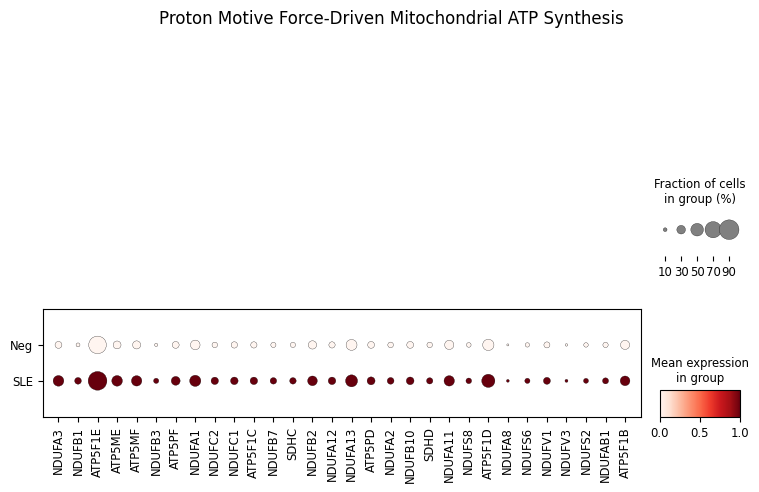

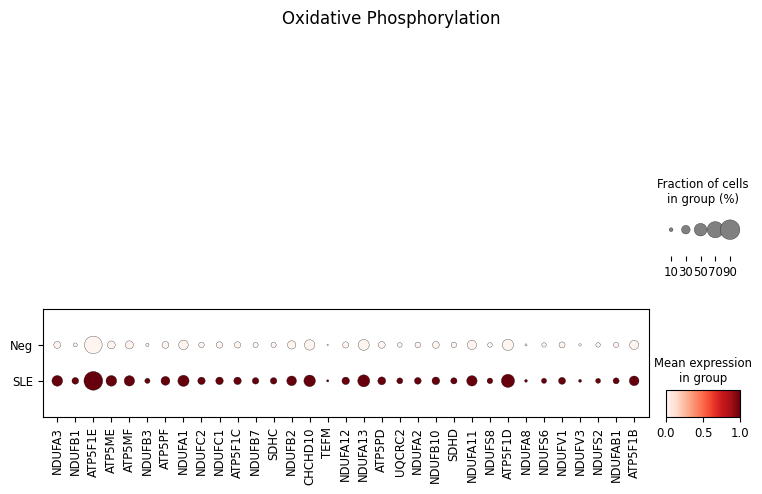

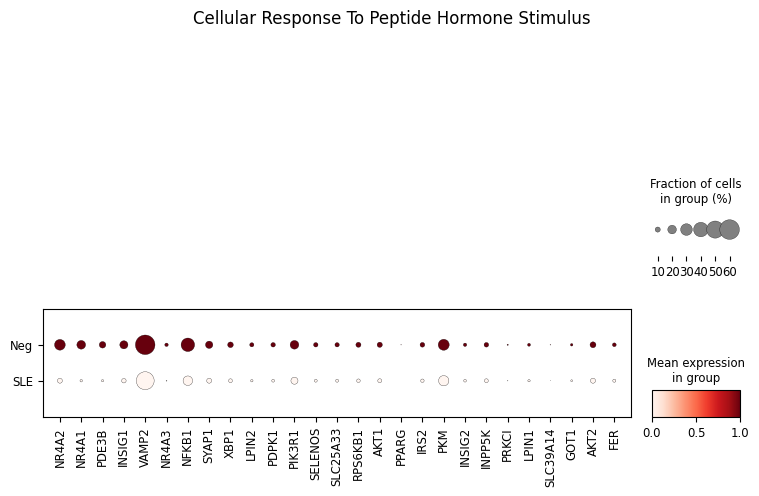

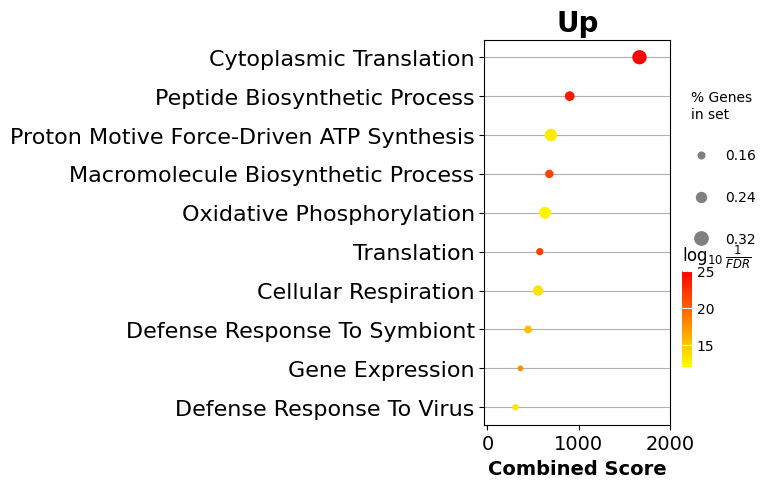

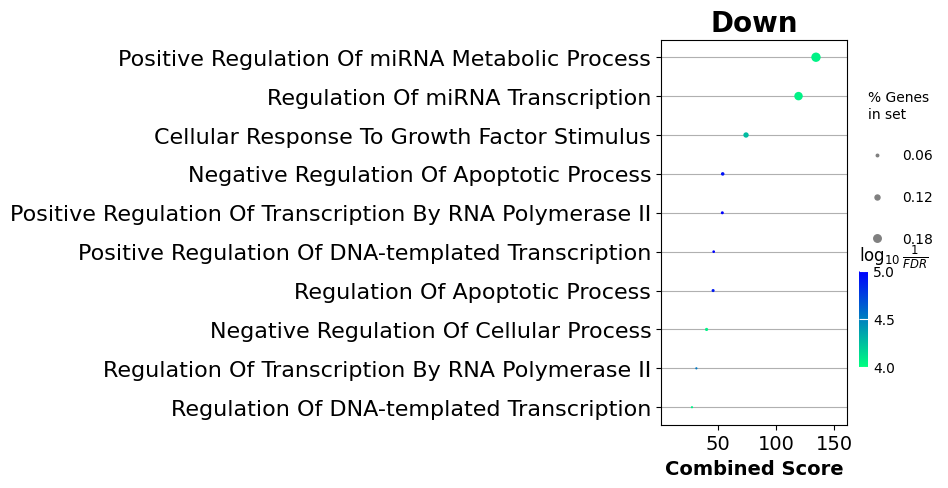

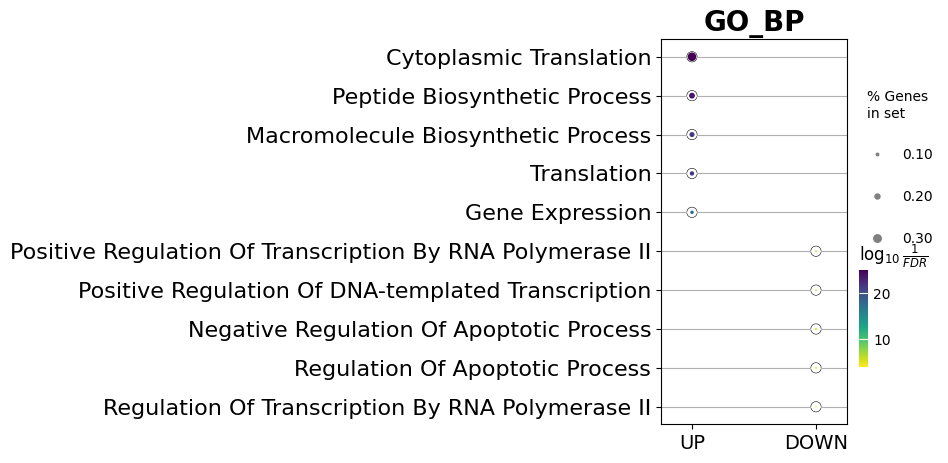

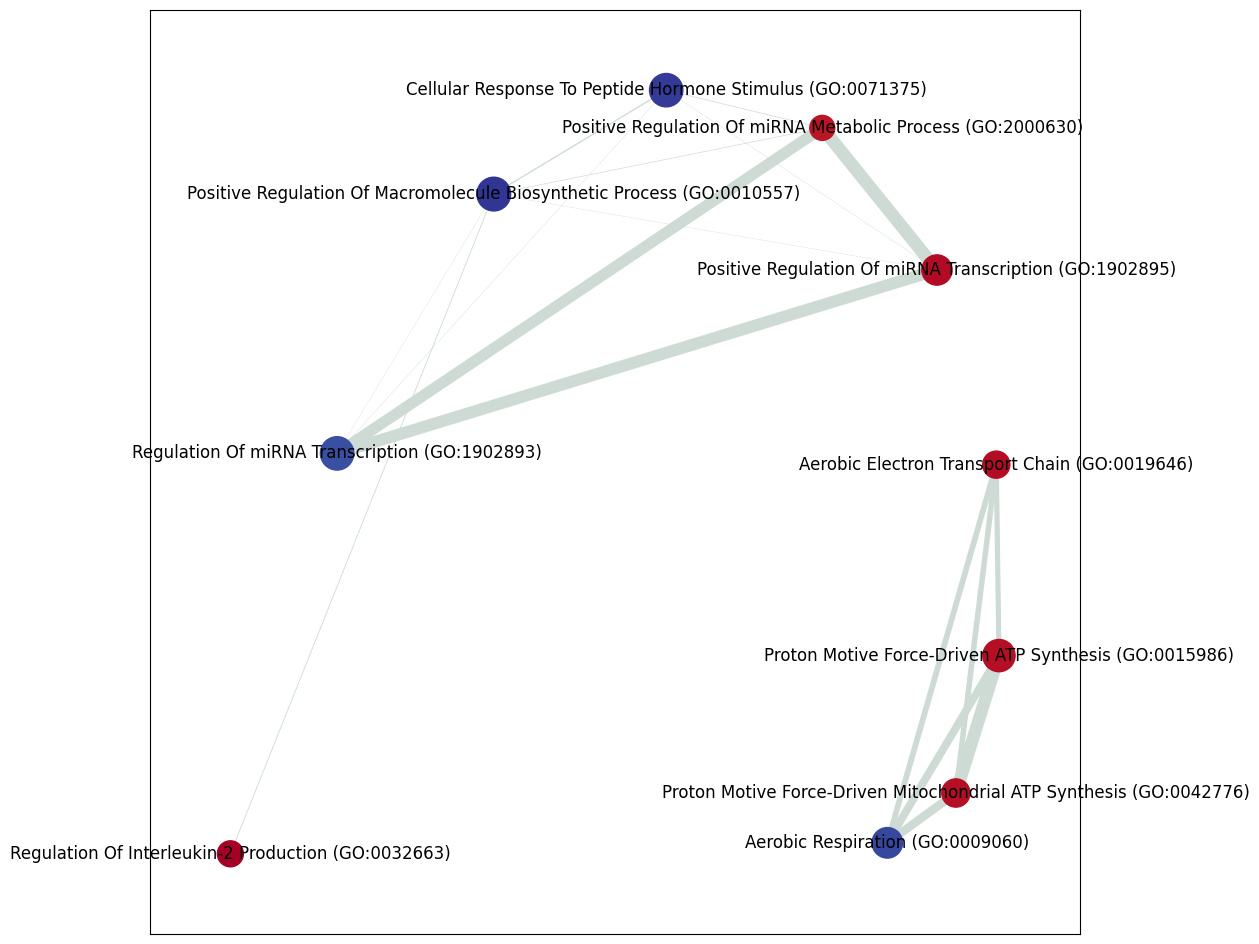

In [250]:
GSEApy_process(
    adata=naive_b,
    top_pathway_type="dotplot",
    groupby="disease_class",
    referencegroup="Neg",
    wanted_group="SLE",
    geneset="GO_Biological_Process_2023",
    outdir_path=Path().cwd().joinpath("testfunc")
)

In [217]:
# this converts the "Term" and "Lead_genes" columns into a dict for the number of top pathways specified
term_gene_dict = {
    x[1]["Term"]: x[1]["Lead_genes"].split(";")
    for i, x
    in enumerate(gs.res2d.iterrows())
    if i < top_x_pathways
}

In [221]:
term_gene_dict = {
        re.sub(pattern=r"\s\(GO:[0-9]+\)", repl="", string=x[1]["Term"]): x[1]["Lead_genes"].split(";")
        for i, x
        in enumerate(gs.res2d.iterrows())
        if i < top_x_pathways
    }

In [226]:
term_name = 'Regulation Of miRNA Transcription'

In [222]:
term_gene_dict['Regulation Of miRNA Transcription']

['FOS',
 'JUN',
 'TGFB1',
 'RARA',
 'EGR1',
 'HIF1A',
 'NR3C1',
 'KLF4',
 'STAT3',
 'TNF',
 'PPARD',
 'SMAD3',
 'FOXO3',
 'PPARG']

In [ ]:
ter

In [228]:
outdir_path

'testing_output'

In [235]:
Path(outdir_path).absolute()

PosixPath('/home/milo/workspace/easyGSEApy/tests/testing_output')

In [231]:
term_name

'Regulation Of miRNA Transcription'

In [236]:
str(Path(outdir_path).absolute().joinpath(f"{term_name}_Heatmap.png"))

'/home/milo/workspace/easyGSEApy/tests/testing_output/Regulation Of miRNA Transcription_Heatmap.png'

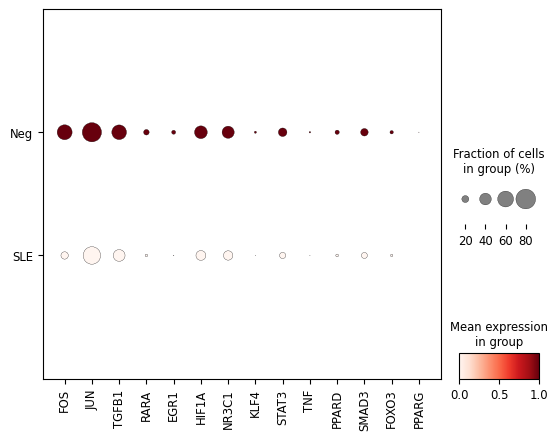

In [240]:
fig, ax = plt.subplots()
g = sc.pl.dotplot(
    adata=naive_b,
    var_names=term_gene_dict[term_name],
    standard_scale="var",
    groupby="disease_class",
    figsize=(9,5),
    show=False,
    ax=ax,
    # save="stuff.png", #"Path(outdir_path).absolute().joinpath(f"{term_name}_Heatmap.png")
    # show_gene_labels=True,
)

ax.figure.savefig(Path(outdir_path).absolute().joinpath(f"{term_name}_Heatmap.png"))

In [242]:
term = gs.res2d.Term

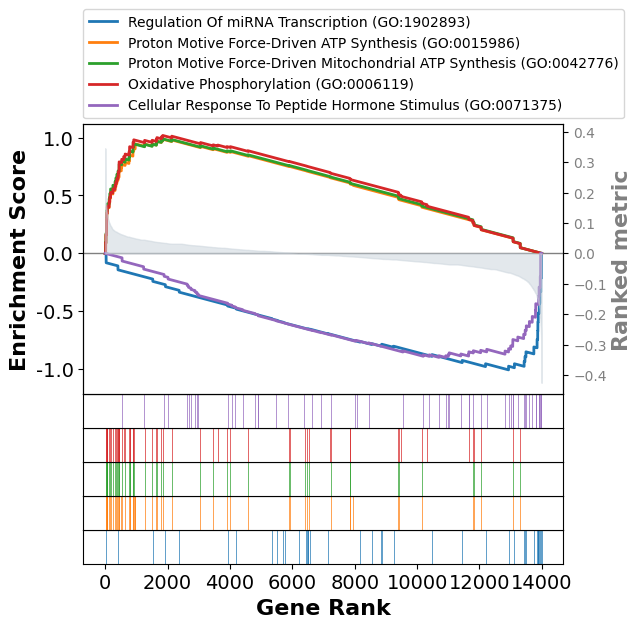

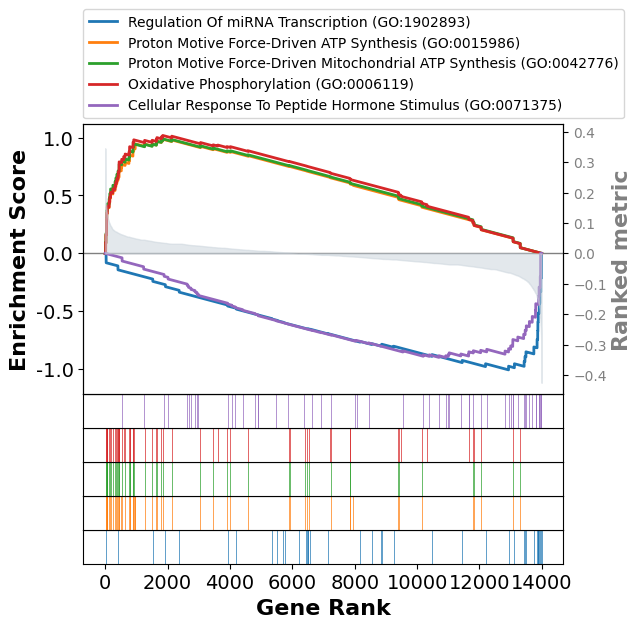

In [243]:
gs.plot(terms=term[:5])

In [204]:
import re

In [205]:
re.sub(pattern=r"\s\(GO:[0-9]+\)", repl="", string=gs.res2d.Term.iloc[i])

'NADH Dehydrogenase (Ubiquinone) Activity'

In [183]:
gs.res2d.Term.iloc[0]

'R-SMAD Binding (GO:0070412)'